## Imports

In [1]:
import mne
import numpy as np
import polars as pl
from utils import APEN
from train_kfold import *

# Preprocessing

### Loading the data:

In [2]:
#raw_X = np.load("../CHB-MIT_Formating/npy_data/chb05/X.npy")
#raw_y = np.load("../CHB-MIT_Formating/npy_data/chb05/y.npy").astype(np.int64)

raw_X = np.concatenate([
    np.load("../CHB-MIT_Formating/npy_data/chb01/X.npy"),
    np.load("../CHB-MIT_Formating/npy_data/chb02/X.npy"),
    np.load("../CHB-MIT_Formating/npy_data/chb03/X.npy"),
], axis=0)

raw_y = np.concatenate([
    np.load("../CHB-MIT_Formating/npy_data/chb01/y.npy"),
    np.load("../CHB-MIT_Formating/npy_data/chb02/y.npy"),
    np.load("../CHB-MIT_Formating/npy_data/chb03/y.npy"),
], axis=0)

print("Raw X shape:", raw_X.shape)
print("Raw y shape:", raw_y.shape)

Raw X shape: (409753, 23, 256)
Raw y shape: (409753,)


### Transforming the data into a DataFrame:

In [3]:
chanelsNames = ["FP1-F7", "F7-T7", "T7-P7", "P7-O1", "FP1-F3", "F3-C3", "C3-P3", "P3-O1", "FP2-F4", "F4-C4", "C4-P4", "P4-O2", "FP2-F8", "F8-T8", "T8-P8-0", "P8-O2", "FZ-CZ", "CZ-PZ", "P7-T7", "T7-FT9", "FT9-FT10", "FT10-T8", "T8-P8-1"]
df = pl.LazyFrame(raw_X.tolist(), schema=[chanelsNames[i] for i in range(raw_X.shape[1])])

/var/folders/7m/6x53syk95817z_4293gmf06w0000gn/T/ipykernel_80346/3286537047.py:2: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  df = pl.LazyFrame(raw_X.tolist(), schema=[chanelsNames[i] for i in range(raw_X.shape[1])])


In [4]:
test = df.collect()
print(test.shape)
print(test.describe())
test.head()

(409753, 23)
shape: (9, 24)
┌────────────┬──────────┬──────────┬──────────┬───┬──────────┬──────────┬──────────┬──────────┐
│ statistic  ┆ FP1-F7   ┆ F7-T7    ┆ T7-P7    ┆ … ┆ T7-FT9   ┆ FT9-FT10 ┆ FT10-T8  ┆ T8-P8-1  │
│ ---        ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str        ┆ f64      ┆ f64      ┆ f64      ┆   ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╪══════════╪═══╪══════════╪══════════╪══════════╪══════════╡
│ count      ┆ 409753.0 ┆ 409753.0 ┆ 409753.0 ┆ … ┆ 409753.0 ┆ 409753.0 ┆ 409753.0 ┆ 409753.0 │
│ null_count ┆ 0.0      ┆ 0.0      ┆ 0.0      ┆ … ┆ 0.0      ┆ 0.0      ┆ 0.0      ┆ 0.0      │
│ mean       ┆ null     ┆ null     ┆ null     ┆ … ┆ null     ┆ null     ┆ null     ┆ null     │
│ std        ┆ null     ┆ null     ┆ null     ┆ … ┆ null     ┆ null     ┆ null     ┆ null     │
│ min        ┆ null     ┆ null     ┆ null     ┆ … ┆ null     ┆ null     ┆ null     ┆ null     │
│ 25%       

FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,C4-P4,P4-O2,FP2-F8,F8-T8,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1
list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64]
"[-0.000146, 1.9536e-7, … -0.000008]","[-0.000105, 1.9536e-7, … 0.000022]","[-0.000043, 1.9536e-7, … 0.000029]","[-0.000033, 1.9536e-7, … 0.000017]","[-0.000171, 1.9536e-7, … 0.000011]","[-0.000111, 1.9536e-7, … 0.000025]","[0.000012, 1.9536e-7, … 0.000004]","[-0.000056, 1.9536e-7, … 0.000018]","[-0.000139, 1.9536e-7, … 0.000026]","[-0.000001, 1.9536e-7, … -0.000007]","[0.000064, 1.9536e-7, … 0.000012]","[-0.000014, 1.9536e-7, … 0.00001]","[-0.000268, 1.9536e-7, … 0.000026]","[0.000057, 1.9536e-7, … -0.000029]","[0.000045, 1.9536e-7, … 0.000057]","[0.000075, 1.9536e-7, … -0.000012]","[-0.000106, 1.9536e-7, … 0.000006]","[0.000085, 1.9536e-7, … 0.000003]","[0.000043, 1.9536e-7, … -0.000029]","[-0.000057, 1.9536e-7, … -0.000003]","[-0.000265, 1.9536e-7, … 0.000018]","[0.000095, 1.9536e-7, … -0.000007]","[0.000045, 1.9536e-7, … 0.000057]"
"[-0.000009, -0.000006, … -9.7680e-7]","[0.000028, 0.00002, … -0.000047]","[0.000018, 0.000007, … -0.000017]","[0.000022, 0.000024, … -0.000028]","[0.000009, 0.000008, … -0.000022]","[0.000028, 0.000027, … -0.000032]","[5.8608e-7, -0.000002, … -0.000011]","[0.000021, 0.000012, … -0.000027]","[0.000017, 0.000002, … -0.000042]","[-0.000006, -0.000003, … -0.000039]","[0.000007, 0.000003, … -0.000002]","[0.000005, 0.000003, … -0.000009]","[0.000019, 0.000011, … -0.000059]","[-0.000015, -0.00001, … -0.000026]","[0.000042, 0.000036, … -0.000024]","[-0.000021, -0.000032, … 0.000016]","[0.00001, 0.000012, … -0.000053]","[-0.000004, -0.00001, … 0.000008]","[-0.000018, -0.000006, … 0.000017]","[-0.000016, -0.000014, … 0.00004]","[0.00003, 0.000035, … -0.000069]","[0.000006, 0.000012, … -0.000013]","[0.000042, 0.000036, … -0.000024]"
"[-0.000037, -0.000041, … -0.000062]","[-0.000044, -0.000048, … -0.000001]","[-0.000015, -0.000008, … -0.000027]","[-0.00001, -0.000006, … -0.000014]","[-0.000054, -0.000061, … -0.000063]","[-0.000033, -0.00003, … 0.000012]","[-0.000005, 1.9536e-7, … -0.000019]","[-0.000014, -0.000013, … -0.000035]","[-0.000017, -0.000041, … 0.00005]","[-0.00004, -0.000026, … 9.7680e-7]","[-9.7680e-7, 1.9536e-7, … 0.000008]","[-9.7680e-7, 0.000001, … 0.000008]","[-0.000044, -0.00006, … 0.000023]","[-0.000015, -0.000004, … -0.00001]","[-0.000018, -0.000015, … 0.000023]","[0.000017, 0.000012, … 0.000033]","[-0.000051, -0.000052, … 0.000015]","[0.000015, 0.000026, … 0.000014]","[0.000016, 0.000008, … 0.000028]","[0.000031, 0.000036, … 0.000024]","[-0.000055, -0.000046, … -0.000043]","[-0.000008, -0.000004, … 0.000003]","[-0.000018, -0.000015, … 0.000023]"
"[-0.000055, 0.000023, … 0.000037]","[-0.000007, -0.00001, … -0.000064]","[-0.000006, 0.000013, … 0.00009]","[-0.000006, 0.000016, … -0.000022]","[-0.000051, 0.000019, … 0.000053]","[0.000009, 0.000012, … 0.000004]","[-0.000016, -0.000004, … -0.000015]","[-0.000017, 0.000015, … 1.9536e-7]","[0.000034, 0.000031, … -0.000047]","[0.000005, 0.000011, … -0.000005]","[0.000013, 0.000021, … 0.000006]","[0.00001, 0.000015, … -0.000012]","[0.00001, 0.000009, … -0.000024]","[-1.9536e-7, 0.000003, … -0.000033]","[0.000018, 0.000031, … 0.000033]","[0.000037, 0.000037, … -0.000035]","[0.000018, 0.000017, … 5.8608e-7]","[0.000015, 0.000023, … 0.000009]","[0.000006, -0.000013, … -0.00009]","[0.000018, 0.000011, … 0.000073]","[-0.000038, -0.000033, … 0.000017]","[0.000011, 0.000013, … -0.000014]","[0.000018, 0.000031, … 0.000033]"
"[0.000001, -0.000028, … 0.000037]","[-0.000017, 0.000006, … -0.000019]","[0.000054, 0.00006, … 0.000006]","[-0.000032, -0.000016, … 0.000023]","[0.000017, -0.000021, … 0.000014]","[0.000002, 0.000012, … 0.000005]","[-0.000009, 0.000005, … 0.000004]","[-0.0000

### Feature extraction:

In [5]:
df_features = df.lazy().with_columns(
    [pl.col(c).map_elements(
        lambda s: APEN(s.to_numpy()),
        return_dtype=pl.Float64,
    ).cast(pl.Float32).alias(f"APEN_{c}")
    for c in chanelsNames]
)

In [6]:
columns = [f"APEN_{c}" for c in chanelsNames]
df_features = df_features.select(columns).collect()

In [7]:
print(df_features.shape)
print(df_features.describe())
df_features.head()

(409753, 23)
shape: (9, 24)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ APEN_FP1- ┆ APEN_F7-T ┆ APEN_T7-P ┆ … ┆ APEN_T7-F ┆ APEN_FT9- ┆ APEN_FT10 ┆ APEN_T8- │
│ ---       ┆ F7        ┆ 7         ┆ 7         ┆   ┆ T9        ┆ FT10      ┆ -T8       ┆ P8-1     │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 409753.0  ┆ 409753.0  ┆ 409753.0  ┆ … ┆ 409753.0  ┆ 409753.0  ┆ 409753.0  ┆ 409753.0 │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ mean      ┆ 0.750709  ┆ 0.787846  ┆ 0.793791  ┆ … ┆ 0.868497 

APEN_FP1-F7,APEN_F7-T7,APEN_T7-P7,APEN_P7-O1,APEN_FP1-F3,APEN_F3-C3,APEN_C3-P3,APEN_P3-O1,APEN_FP2-F4,APEN_F4-C4,APEN_C4-P4,APEN_P4-O2,APEN_FP2-F8,APEN_F8-T8,APEN_T8-P8-0,APEN_P8-O2,APEN_FZ-CZ,APEN_CZ-PZ,APEN_P7-T7,APEN_T7-FT9,APEN_FT9-FT10,APEN_FT10-T8,APEN_T8-P8-1
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
0.565509,0.885671,0.885718,0.842593,0.630252,0.791597,0.684918,0.835042,0.64538,0.711524,0.690493,0.943163,0.828403,0.894927,0.872674,0.945557,0.722681,0.509958,0.885718,0.979189,0.810435,0.930305,0.872674
0.549862,0.822518,0.964958,0.972649,0.58186,0.7349,0.740014,0.965181,0.548784,0.706429,0.704155,0.854571,0.743953,0.935837,0.907139,0.866292,0.67383,0.84536,0.964958,0.910561,0.764306,0.950475,0.907139
0.933756,0.936984,0.935382,0.925278,0.955964,1.024254,0.898618,0.875141,0.905189,0.912164,0.878371,0.942549,0.94079,0.95343,0.939601,0.918629,0.726584,0.685798,0.935382,1.021976,0.814328,0.91775,0.939601
0.82454,0.817761,0.834745,0.887308,0.913741,0.88112,0.895834,0.830101,0.903719,0.910377,0.833468,0.962829,0.85856,0.906276,0.913889,0.929977,0.802567,0.693865,0.834745,0.835417,0.816916,0.93076,0.913889
0.776572,0.827409,0.759134,0.869767,0.916543,0.886498,0.891667,0.894755,0.840409,0.891144,0.807955,0.948604,0.855802,0.834622,0.867649,0.975637,0.757343,0.723386,0.759134,0.846737,0.900121,0.910032,0.867649


### Making Final dataset

Checking uniformity of the windows length:

In [8]:
df = df.collect()

lens = df.select(pl.all().list.len())
assert np.all(lens.to_numpy() == lens.to_numpy()[0, 0]), "windows have different lengths"
T = lens.row(0)[0]

In [9]:
channels = df.columns

X_eeg = np.stack(
    [df[c].list.to_array(T).to_numpy() for c in channels],  # each is (N, T)
    axis=1,
).astype(np.float32)                                          # -> (N, C, T)

X_features = df_features.to_numpy().astype(np.float32)                     # -> (N, F)

y = raw_y

print(X_eeg.shape)  # e.g. (5, 23, T)
print(X_features.shape)  # e.g. (5, 23)
print(y.shape)  # e.g. (5,)

(409753, 23, 256)
(409753, 23)
(409753,)


# Training Tests
In this section, we will train and evaluate the new architecture using differnt entropy estimators as complementary features.

In [10]:
N_SPLITE      = 10
EPOCHS        = 15
BATCH_SIZE    = 32
LEARNING_RATE = 1e-3

## Approximate entropy (APEN)

fold  1/10 | train counts [367863, 914] | class weights [0.5, 201.74]
    epoch  0 | train 0.1243 | val 1.2794 | acc 0.702 | bal acc 0.729 | AUPRC 0.013
    epoch  1 | train 0.0632 | val 0.4420 | acc 0.994 | bal acc 0.904 | AUPRC 0.552
    epoch  2 | train 0.0518 | val 0.2686 | acc 0.996 | bal acc 0.915 | AUPRC 0.625
    epoch  3 | train 0.0489 | val 0.9898 | acc 0.479 | bal acc 0.724 | AUPRC 0.043
    epoch  4 | train 0.0483 | val 0.2614 | acc 0.997 | bal acc 0.906 | AUPRC 0.689
    epoch  5 | train 0.0460 | val 0.2670 | acc 0.994 | bal acc 0.924 | AUPRC 0.619
    epoch  6 | train 0.0420 | val 0.2404 | acc 0.926 | bal acc 0.934 | AUPRC 0.411
    epoch  7 | train 0.0456 | val 0.1648 | acc 0.989 | bal acc 0.941 | AUPRC 0.609
    epoch  8 | train 0.0438 | val 0.2854 | acc 0.995 | bal acc 0.924 | AUPRC 0.668
    epoch  9 | train 0.0391 | val 0.2754 | acc 0.995 | bal acc 0.929 | AUPRC 0.703
    epoch 10 | train 0.0423 | val 0.8134 | acc 0.968 | bal acc 0.925 | AUPRC 0.448
    epoch 11 | tr

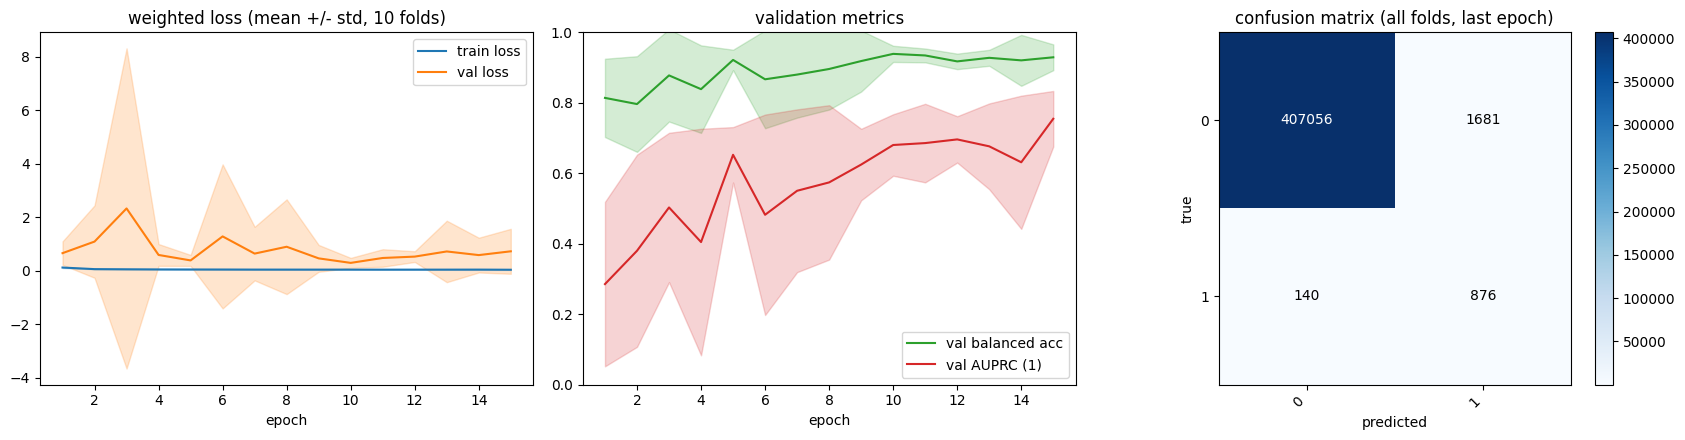


CV over 10 folds | balanced acc 0.9291 +/- 0.0367 | AUPRC 0.7546 +/- 0.0789


ValueError: too many values to unpack (expected 2, got 3)

In [11]:
X_features = X_features.reshape(len(y), -1)                      # (N, F) — force 2D
model, hist = train_model(X_eeg, X_features, y, n_splits=N_SPLITE, batch_size=BATCH_SIZE, epochs=EPOCHS, lr=LEARNING_RATE)

## Controle group

In [ ]:
X_features_ctrl = np.zeros((len(y), 23), dtype=np.float32)   # (N, 23)
fold_histories, fold_scores, model = train_model(X_eeg, X_features_ctrl, y, n_splits=N_SPLITE, batch_size=BATCH_SIZE, epochs=EPOCHS, lr=LEARNING_RATE)

fold  1/10 | train counts [367863, 914] | class weights [0.5, 201.74]
    epoch  0 | train 0.0848 | val 26.0818 | acc 0.002 | bal acc 0.500 | AUPRC 0.002


## Denoised signal performance

In [ ]:
from denois import atar

X_Dennoised = atar(X_eeg)
X_features = X_features.reshape(len(y), -1)                      # (N, F) — force 2D

In [ ]:
fold_histories, fold_accs, model = train_model(X_serie, X_features, y, n_splits=N_SPLITE, batch_size=BATCH_SIZE, epochs=EPOCHS, lr=LEARNING_RATE)